#Backtest of Momentum Strategy


In [31]:
import pandas as pd
import numpy as np
import yfinance as yf

In [32]:
tickers = ["AAPL","MSFT","AMZN","GOOGL","META","NVDA","JPM","XOM"]

data = yf.download(tickers, start="2015-01-01")["Close"]

/tmp/ipykernel_835/1146800706.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2015-01-01")["Close"]
[*********************100%***********************]  8 of 8 completed


returns and momentum

In [33]:
returns = data.pct_change()
momentum = data.pct_change(252)
print(returns)
print(momentum)

rank = momentum.rank(axis=1, pct=True)

long = rank > 0.7
short = rank < 0.3

print(long)
print(short)

Ticker          AAPL      AMZN     GOOGL       JPM      META      MSFT  \
Date                                                                     
2015-01-02       NaN       NaN       NaN       NaN       NaN       NaN   
2015-01-05 -0.028172 -0.020517 -0.019054 -0.031045 -0.016061 -0.009196   
2015-01-06  0.000094 -0.022833 -0.024679 -0.025929 -0.013473 -0.014677   
2015-01-07  0.014022  0.010600 -0.002941  0.001526  0.000000  0.012705   
2015-01-08  0.038422  0.006836  0.003484  0.022347  0.026658  0.029418   
...              ...       ...       ...       ...       ...       ...   
2026-03-03 -0.003664  0.001632 -0.009592  0.009074  0.002326  0.013499   
2026-03-04 -0.004664  0.038758 -0.001482 -0.002897  0.019311  0.003144   
2026-03-05 -0.008495  0.009778 -0.007423 -0.019506 -0.010723  0.013524   
2026-03-06 -0.010873 -0.026172 -0.007844 -0.013865 -0.023783 -0.004188   
2026-03-09 -0.004331 -0.020214  0.000000 -0.025805 -0.019942  0.000000   

Ticker          NVDA       XOM  
Date

/tmp/ipykernel_835/1584591677.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change()
/tmp/ipykernel_835/1584591677.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  momentum = data.pct_change(252)


Returns of the strategy

In [34]:
strategy_returns = (returns * long - returns * short).mean(axis=1)
print(strategy_returns)

Date
2015-01-02         NaN
2015-01-05    0.000000
2015-01-06    0.000000
2015-01-07    0.000000
2015-01-08    0.000000
                ...   
2026-03-03   -0.005295
2026-03-04   -0.002571
2026-03-05   -0.000289
2026-03-06    0.001873
2026-03-09    0.004309
Length: 2811, dtype: float64


sharpe ratio and plot of cumulative returns

1.9120588812963144


<Axes: xlabel='Date'>

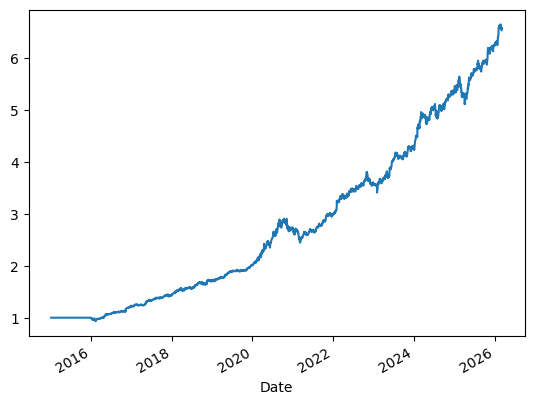

In [35]:
sharpe = strategy_returns.mean() / strategy_returns.std() * np.sqrt(252)
print(sharpe)
(strategy_returns + 1).cumprod().plot()

Comparison with S&P500 and naive equal weight portfolio

In [36]:
import yfinance as yf

spy = yf.download("SPY", start="2015-01-01")["Close"]

spy_returns = spy.pct_change()
spy_returns = spy_returns.reindex(strategy_returns.index)

/tmp/ipykernel_835/4254213084.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download("SPY", start="2015-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed


In [37]:
#equal weights of used stocks in the momentum strategy
equal_weight_returns = returns.mean(axis=1)


Returns of all 3 strategies

In [38]:
cum_momentum = (1 + strategy_returns).cumprod()
cum_spy = (1 + spy_returns).cumprod()
cum_equal = (1 + equal_weight_returns).cumprod()

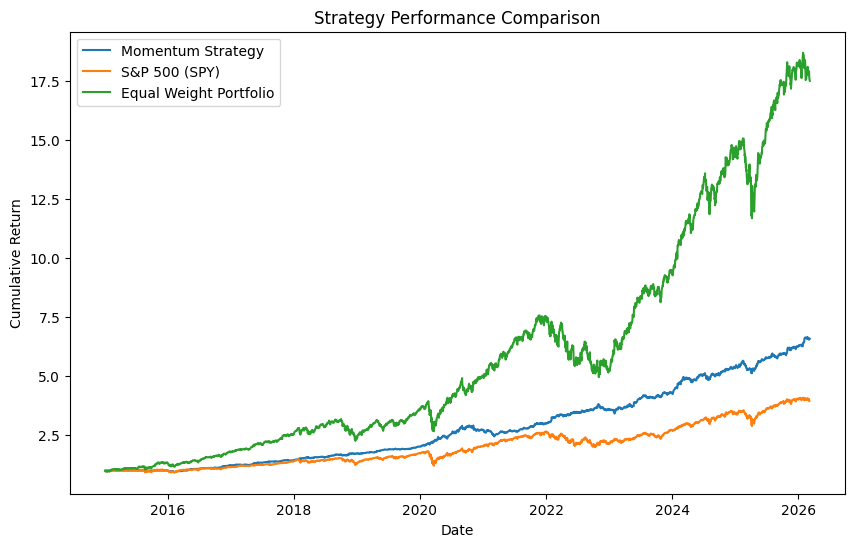

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(cum_momentum, label="Momentum Strategy")
plt.plot(cum_spy, label="S&P 500 (SPY)")
plt.plot(cum_equal, label="Equal Weight Portfolio")

plt.title("Strategy Performance Comparison")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()

plt.show()

In [40]:
import numpy as np

def performance_stats(returns):

    annual_return = returns.mean() * 252
    annual_vol = returns.std() * np.sqrt(252)
    sharpe = annual_return / annual_vol
    max_drawdown = ((1 + returns).cumprod().cummax() - (1 + returns).cumprod()).max()

    return annual_return, annual_vol, sharpe, max_drawdown

mom_stats = performance_stats(strategy_returns)
spy_stats = performance_stats(spy_returns)
eq_stats = performance_stats(equal_weight_returns)

import pandas as pd

stats = pd.DataFrame({
    "Momentum": performance_stats(strategy_returns),
    "S&P500": performance_stats(spy_returns),
    "Equal Weight": performance_stats(equal_weight_returns)
},
index=["Annual Return","Volatility","Sharpe Ratio","Max Drawdown"])

print(stats)

               Momentum                                 S&P500  Equal Weight
Annual Return  0.173114  Ticker
SPY    0.138804
dtype: float64      0.284466
Volatility     0.090538  Ticker
SPY    0.177146
dtype: float64      0.235216
Sharpe Ratio   1.912059  Ticker
SPY    0.783556
dtype: float64      1.209383
Max Drawdown   0.530263  Ticker
SPY    0.666055
dtype: float64      3.376176


This could all be a bit overrated, as we already knew these stock would perform good. So let's select some more 'random'stocks. Namely: Apple Inc., GameStop Corp., MacroGenics Inc., SoFi Technologies Inc., Palantir Technologies Inc., Penn Entertainment Inc., NIO Inc., and Microsoft Corporation.

In [41]:
tickers = ["AAPL", "GME", "MGNX", "SOFI", "PLTR", "PENN", "NIO", "MSFT"]
data = yf.download(tickers, start="2015-01-01")["Close"]

returns = data.pct_change()
momentum = data.pct_change(252)
print(returns)
print(momentum)

rank = momentum.rank(axis=1, pct=True)

long = rank > 0.7
short = rank < 0.3

print(long)
print(short)

strategy_returns = (returns * long - returns * short).mean(axis=1)
print(strategy_returns)

/tmp/ipykernel_835/703669993.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2015-01-01")["Close"]
[*********************100%***********************]  8 of 8 completed


Ticker          AAPL       GME      MGNX      MSFT       NIO      PENN  \
Date                                                                     
2015-01-02       NaN       NaN       NaN       NaN       NaN       NaN   
2015-01-05 -0.028171  0.027219 -0.012791 -0.009196       NaN -0.021513   
2015-01-06  0.000094 -0.029666 -0.054420 -0.014677       NaN  0.001516   
2015-01-07  0.014023 -0.011576  0.088307  0.012706       NaN  0.077214   
2015-01-08  0.038422  0.011712  0.007834  0.029418       NaN  0.020380   
...              ...       ...       ...       ...       ...       ...   
2026-03-03 -0.003664 -0.015703 -0.020619  0.013499 -0.027542  0.005387   
2026-03-04 -0.004664  0.002099  0.094737  0.003144  0.054466  0.022773   
2026-03-05 -0.008495  0.000419  0.028846  0.013524 -0.024793  0.013098   
2026-03-06 -0.010873  0.020519  0.042056 -0.004188  0.012712 -0.053652   
2026-03-09 -0.004486 -0.002052  0.033632 -0.009561  0.014623 -0.046790   

Ticker          PLTR      SOFI  
Date

In [42]:
spy = yf.download("SPY", start="2015-01-01")["Close"]

spy_returns = spy.pct_change()
spy_returns = spy_returns.reindex(strategy_returns.index)

equal_weight_returns = returns.mean(axis=1)

cum_momentum = (1 + strategy_returns).cumprod()
cum_spy = (1 + spy_returns).cumprod()
cum_equal = (1 + equal_weight_returns).cumprod()

/tmp/ipykernel_835/2008714918.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download("SPY", start="2015-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed


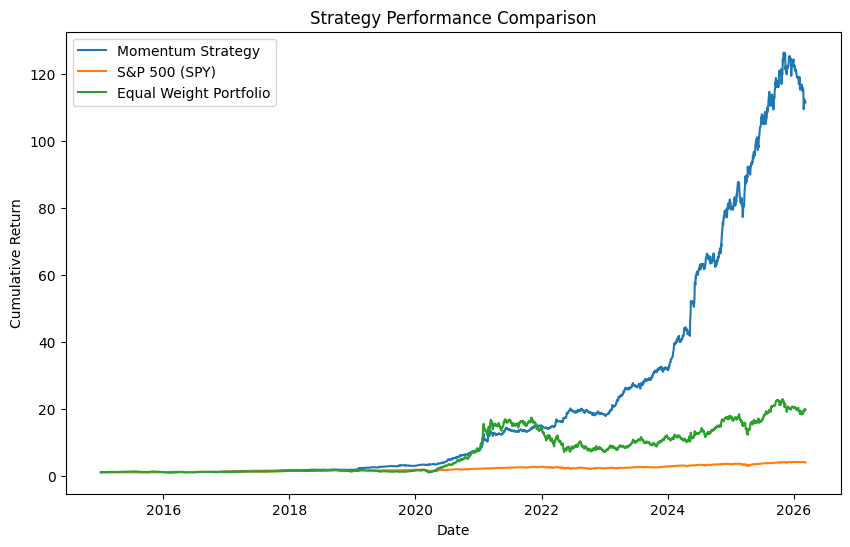

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(cum_momentum, label="Momentum Strategy")
plt.plot(cum_spy, label="S&P 500 (SPY)")
plt.plot(cum_equal, label="Equal Weight Portfolio")

plt.title("Strategy Performance Comparison")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()

plt.show()